In [7]:
!pip install cmake opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [8]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
#경로 설정
image_path = '/home/jovyan/work/camera_sticker/image/selfimage.png'
sticker_path = '/home/jovyan/work/camera_sticker/image/cat.png'
model_path = '/home/jovyan/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat'

In [15]:
#이미지 불러오기
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [17]:
#얼굴 detector
detector = dlib.get_frontal_face_detector()
faces = detector(img_rgb)
print("얼굴 개수:", len(faces))

얼굴 개수: 1


In [19]:
#landmark 모델
predictor = dlib.shape_predictor(model_path)

In [20]:
#스티커 (투명 PNG)
sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

In [21]:
#여백 제거 함수
def crop_transparent(img):
    alpha = img[:, :, 3]
    coords = np.argwhere(alpha > 0)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)

    return img[y0:y1+1, x0:x1+1]

sticker = crop_transparent(sticker)

In [22]:
#알파 블렌딩 함수
def overlay_alpha(bg, fg, x, y):
    h, w = fg.shape[:2]

    for i in range(h):
        for j in range(w):
            if 0 <= y+i < bg.shape[0] and 0 <= x+j < bg.shape[1]:
                alpha = fg[i, j, 3] / 255.0
                bg[y+i, x+j] = (
                    alpha * fg[i, j, :3] +
                    (1 - alpha) * bg[y+i, x+j]
                )
    return bg


In [23]:
# 얼굴마다 수염 붙이기
for face in faces:
    landmarks = predictor(img_rgb, face)

    # 코 양옆 기준 (31, 35)
    left = landmarks.part(31)
    right = landmarks.part(35)

    x = (left.x + right.x) // 2
    y = (left.y + right.y) // 2 + 10  # 살짝 아래

    # 얼굴 크기 기반 스케일
    face_width = face.right() - face.left()
    sticker_width = int(face_width * 0.8)
    sticker_height = int(sticker_width * sticker.shape[0] / sticker.shape[1])

    resized_sticker = cv2.resize(sticker, (sticker_width, sticker_height))


In [25]:
# 중앙 정렬
img = overlay_alpha(
        img,
        resized_sticker,
        x - sticker_width // 2,
        y - sticker_height // 2
    )


(np.float64(-0.5), np.float64(1023.5), np.float64(1535.5), np.float64(-0.5))

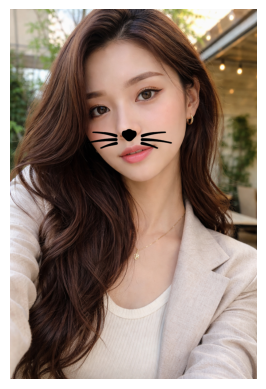

In [26]:
#결과 출력
result = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(result)
plt.axis('off')

In [27]:
print(len(faces))          # 얼굴 인식
print(sticker.shape)       # 4채널인지
print(img is None)         # 이미지 로딩

1
(118, 512, 4)
False
